In [1]:
import os
os.chdir('../../..')

# This workbook contains results for the Euclidean baseline clustering

In [ ]:
import chemiscope
from ase import Atoms  
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import numpy as np
from sklearn.metrics import calinski_harabasz_score
from rdkit import Chem
from loguru import logger
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from src.datasets import QM9Dataset

In [ ]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_all_descriptors(include_chemprop=True)

2026-03-17 14:24:15.281 | INFO     | src.datasets:load:132 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-17 14:24:15.317 | INFO     | src.datasets:add_all_descriptors:491 - Adding all descriptors to QM9 dataframe...
2026-03-17 14:24:15.318 | INFO     | src.features:compute_morgan_fingerprints:57 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-03-17 14:24:18.484 | INFO     | src.features:compute_selfies_transformer:74 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-17 14:24:34.712 | INFO     | src.features:compute_selfies_onehot:116 - Computing One-Hot Encodings...
2026-03-17 14:24:35.383 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-17 14:24:41.160 | SUCCESS  | src.datasets:add_soap:423 - Added SOAP embeddings.
2026-03-17 14:24:41.162 | INFO     | src.features:compute_acsf:174 - Computing ACSF (rcut=6.0)...
2026-03-17 14:24:45.459 | SUCCESS  | src.datasets:add_acsf:433 - Added ACSF embeddings.
2026-03-17 14:24:45.459 | INFO     | src.features:compute_coulomb_matrix:205 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-17 14:24:49.222 | SUCCESS  | src.datasets:add_coulomb_matrix:450 - Added Coulomb matrix descriptors.
2026-03-17 14:24:49.223 | INFO     | src.features:compute_chemprop_embeddings:254 - Computing Chemprop embeddings on mps...
2026-03-17 14:24:49.223 | WARNING  | src.features:compute_chemprop_embeddings:262 - No model_path provided. Using RAND

In [4]:
qm9.df["selfies", "structure_class"][0]["selfies"].to_list()

['[H][C][Branch1][C][H][Branch1][C][H][H]']

In [5]:
X_morgan = np.array(qm9.df['morgan_fingerprint'].to_list())
X_onehot = np.array(qm9.df['selfies_onehot'].to_list())
X_onehot = X_onehot.reshape(X_onehot.shape[0], -1)
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

In [6]:
from config.states import get_num_clusters

embeddings = {
    "onehot": X_onehot,
    "morgan": X_morgan,
    "transformer": X_transformer,
    "chemprop": X_chemprop,
    "soap": X_soap,
    "acsf": X_acsf,
}

cluster_labels = {}

for label, X in embeddings.items():
    n_clusters = get_num_clusters(label)

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10,
    )

    cluster_labels[f"{label}_labels"] = model.fit_predict(X)

qm9.df = qm9.df.with_columns(**cluster_labels)

df = qm9.df.drop([
    "morgan_fingerprint",
    "selfies_onehot",
    "selfies_transformer",
    "chemprop_embedding",
    "soap_embedding",
    "acsf_embedding",
])

#df.write_csv("report/qm9/euclidean_baseline/csv/qm9_clusterlabels.csv")

In [25]:
def get_structures():
    # Extract both the IDs and the SMILES strings
    mol_ids = qm9.df["mol_id"].to_list()
    smiles_list = qm9.df["canonical_smiles"].to_list()

    structures = []
    valid_indices = []  # We need to track this (see warning below)
    functional_groups = []
    structure_types = []

    for i, (mol_id, s) in enumerate(zip(mol_ids, smiles_list)):
        if s is None:
            print(f"Skipping {mol_id}: SMILES is missing.")
            continue

        mol = Chem.MolFromSmiles(s)
        if mol is None:
            print(f"Skipping {mol_id}: RDKit could not parse SMILES.")
            continue

        mol = Chem.AddHs(mol)

        res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        if res != 0:
            print(f"Skipping {mol_id}: Failed to generate 3D conformer.")
            continue

        conf = mol.GetConformer()
        positions = conf.GetPositions()
        numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]

        atoms = Atoms(numbers=numbers, positions=positions)
        structures.append(atoms)
        valid_indices.append(i)

        groups = QM9Dataset._detect_functional_groups(mol)
        functional_groups.append(", ".join(groups) if groups else "none")
        structure_types.append(QM9Dataset._classify_structure_type(mol))

    return structures, valid_indices, functional_groups, structure_types


def plot_clusters(X, embedding_type, valid_indices=None, n_clusters=5):

    if valid_indices is not None:
        X = X[valid_indices]

    n = get_num_clusters(embedding_type)
    logger.info(f"Running {embedding_type} with {n} clusters")

    model = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=labels,
        palette="viridis",
        s=50,
        alpha=0.7,
        edgecolor=None
    )

    plt.title(f"PCA of {embedding_type} Embeddings with KMeans Clustering", fontsize=16, pad=15)
    plt.xlabel("Principal Component 1", fontsize=12)
    plt.ylabel("Principal Component 2", fontsize=12)

    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()


def write_chemiscope(X, label):

    n = get_num_clusters(label)
    logger.info(f"Running {label} with {n} clusters")

    structures, valid_indices, functional_groups, structure_types = get_structures()

    X = X[valid_indices]
    model = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    def _select(col_name):
        values = qm9.df[col_name].to_list()
        return [values[i] for i in valid_indices]

    properties = {
        "PCA 1": X_pca[:, 0],
        "PCA 2": X_pca[:, 1],
        "Cluster": labels,
        #"Mol ID": _select("mol_id"),
        #"SMILES": _select("canonical_smiles"),
        #"SELFIES": _select("selfies"),
        "Structure Class": _select("structure_class"),
       # "Structure Type": structure_types,
        "Functional Groups": functional_groups,
    }

    extra_cols = [
        ("num_atoms", "Num Atoms"),
        ("mol_weight", "Mol Weight"),
        ("logp", "LogP"),
        ("tpsa", "TPSA"),
        ("num_heavy_atoms", "Num Heavy Atoms"),
    #     ("num_rings", "Num Rings"),
    #     ("num_aromatic_rings", "Num Aromatic Rings"),
    #     ("num_rotatable_bonds", "Num Rotatable Bonds"),
        ("fraction_csp1", "Fraction sp1"),
        ("fraction_csp2", "Fraction sp2"),
         ("fraction_csp3", "Fraction sp3"),
    #     ("h_bond_donors", "H Bond Donors"),
    #     ("h_bond_acceptors", "H Bond Acceptors"),
    #     ("mu", "Dipole (mu)"),
    #     ("gap", "HOMO-LUMO Gap"),
    #     ("u0", "Internal Energy (U0)"),
    #     ("cv", "Heat Capacity (Cv)"),
     ]

    for col, label_name in extra_cols:
        if col in qm9.df.columns:
            properties[label_name] = _select(col)

    output_path = "report/qm9/euclidean_baseline/csv/visualization.json.gz"

    chemiscope.write_input(
        output_path,
        structures=structures,
        properties=properties,
    )
    return output_path


- Oxygen: Red
- Nitrogen: Blue
- Hydrogen: White
- Sulfur: Yellow
- Carbon : Grey / Black

# Onehot

In [26]:
output_path = write_chemiscope(X_onehot, 'onehot')
chemiscope.show_input(output_path)
#plot_clusters(X_onehot, 'onehot')

2026-03-17 15:44:30.957 | INFO     | __main__:write_chemiscope:82 - Running onehot with 4 clusters


<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# Morgan

2026-03-17 15:44:39.357 | INFO     | __main__:write_chemiscope:82 - Running morgan with 3 clusters


Skipping qm9_686: Failed to generate 3D conformer.


2026-03-17 15:44:42.369 | INFO     | __main__:plot_clusters:49 - Running morgan with 3 clusters


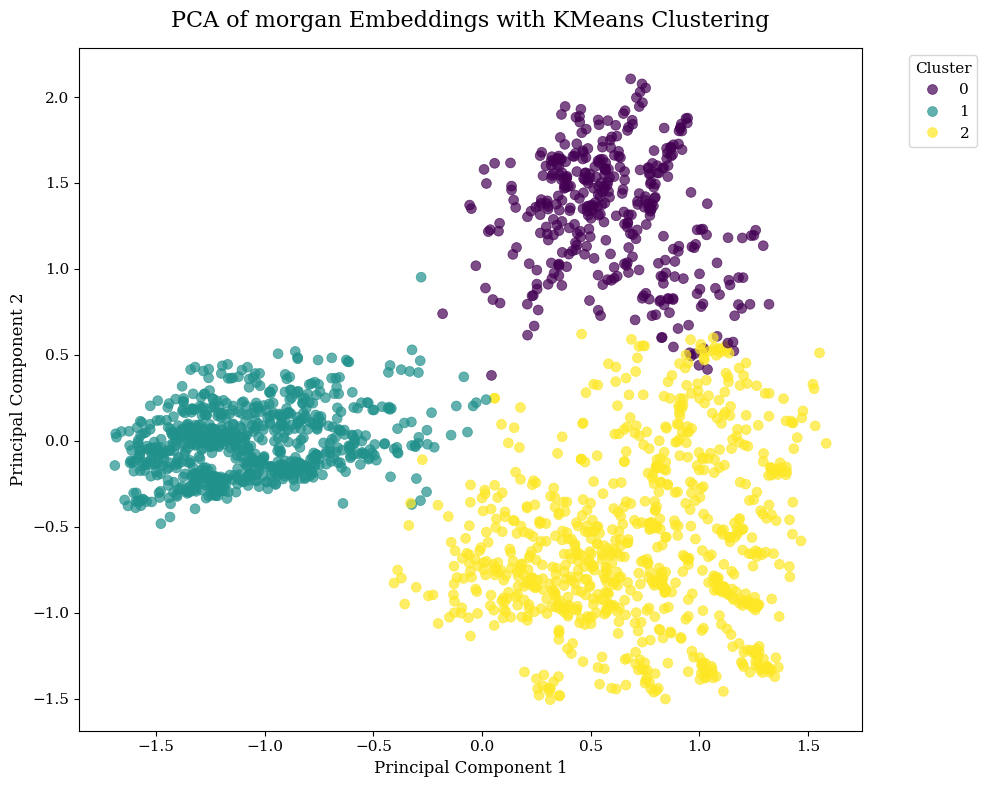

In [27]:
output_path = write_chemiscope(X_morgan, 'morgan')
plot_clusters(X_morgan, 'morgan')

In [28]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# ACSF

2026-03-17 14:25:04.123 | INFO     | __main__:write_chemiscope:82 - Running acsf with 3 clusters


Skipping qm9_686: Failed to generate 3D conformer.
Skipping qm9_1984: Failed to generate 3D conformer.


2026-03-17 14:25:06.740 | INFO     | __main__:plot_clusters:49 - Running acsf with 3 clusters


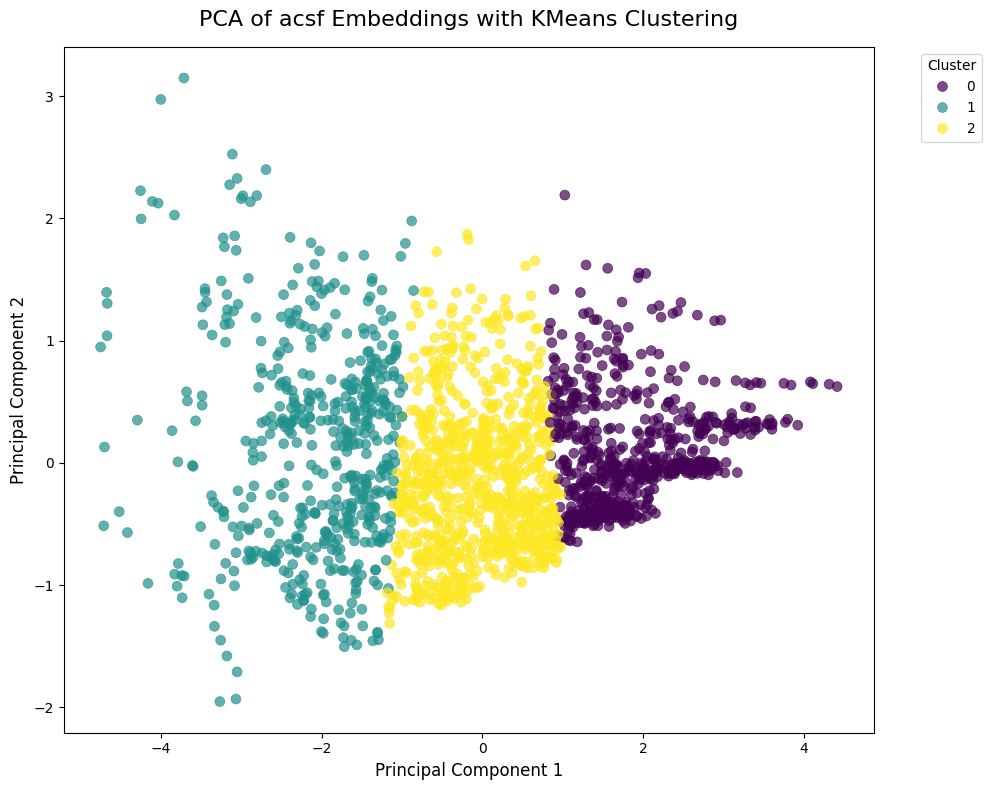

In [11]:
output_path = write_chemiscope(X_acsf, 'acsf')
plot_clusters(X_acsf, 'acsf')

In [12]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# SOAP

2026-03-17 15:44:50.898 | INFO     | __main__:write_chemiscope:82 - Running soap with 4 clusters


Skipping qm9_686: Failed to generate 3D conformer.


2026-03-17 15:44:55.469 | INFO     | __main__:plot_clusters:49 - Running soap with 4 clusters


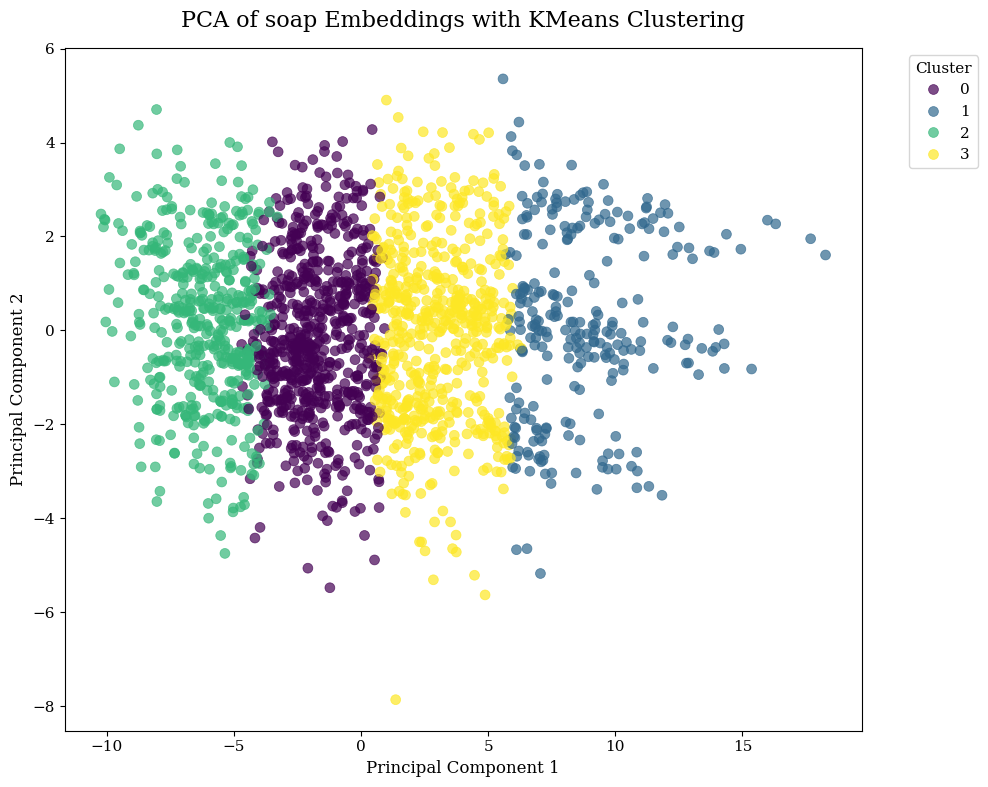

In [29]:
output_path = write_chemiscope(X_soap, 'soap')
plot_clusters(X_soap, 'soap')

In [30]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# Chemprop

2026-03-17 14:25:13.618 | INFO     | __main__:write_chemiscope:82 - Running chemprop with 3 clusters


Skipping qm9_686: Failed to generate 3D conformer.


2026-03-17 14:25:16.468 | INFO     | __main__:plot_clusters:49 - Running chemprop with 3 clusters


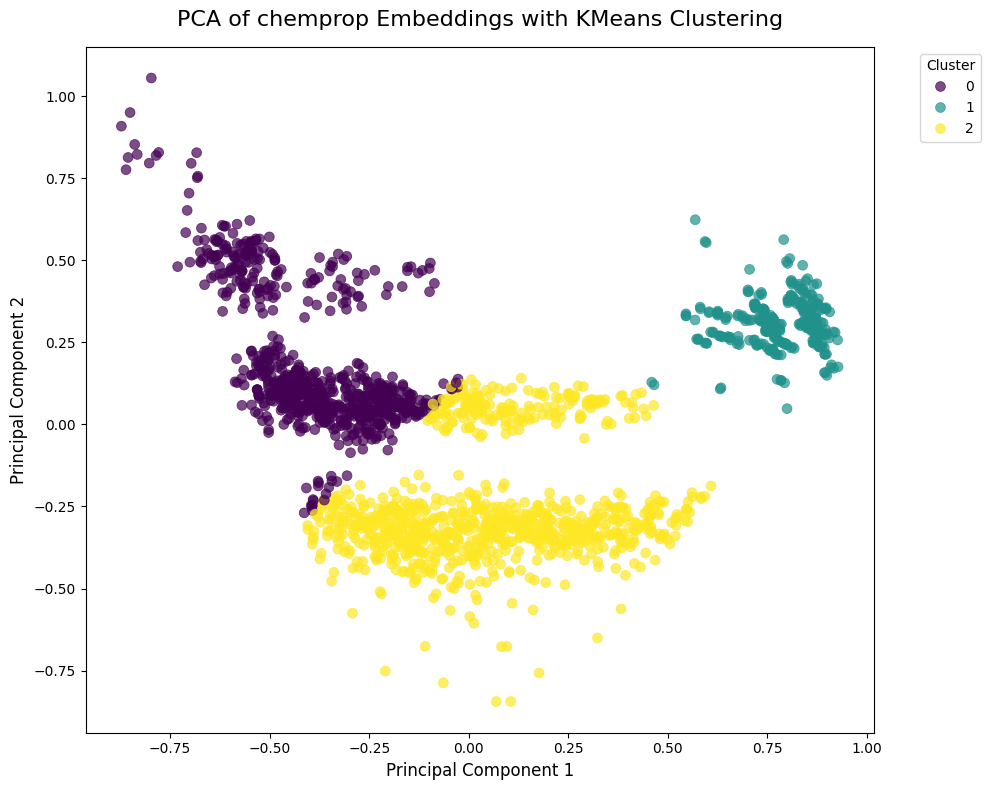

In [15]:
output_path = write_chemiscope(X_chemprop, 'chemprop')
plot_clusters(X_chemprop, 'chemprop')

In [16]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# Transformer

2026-03-17 14:25:16.807 | INFO     | __main__:write_chemiscope:82 - Running transformer with 4 clusters


Skipping qm9_686: Failed to generate 3D conformer.


2026-03-17 14:25:19.454 | INFO     | __main__:plot_clusters:49 - Running transformer with 4 clusters


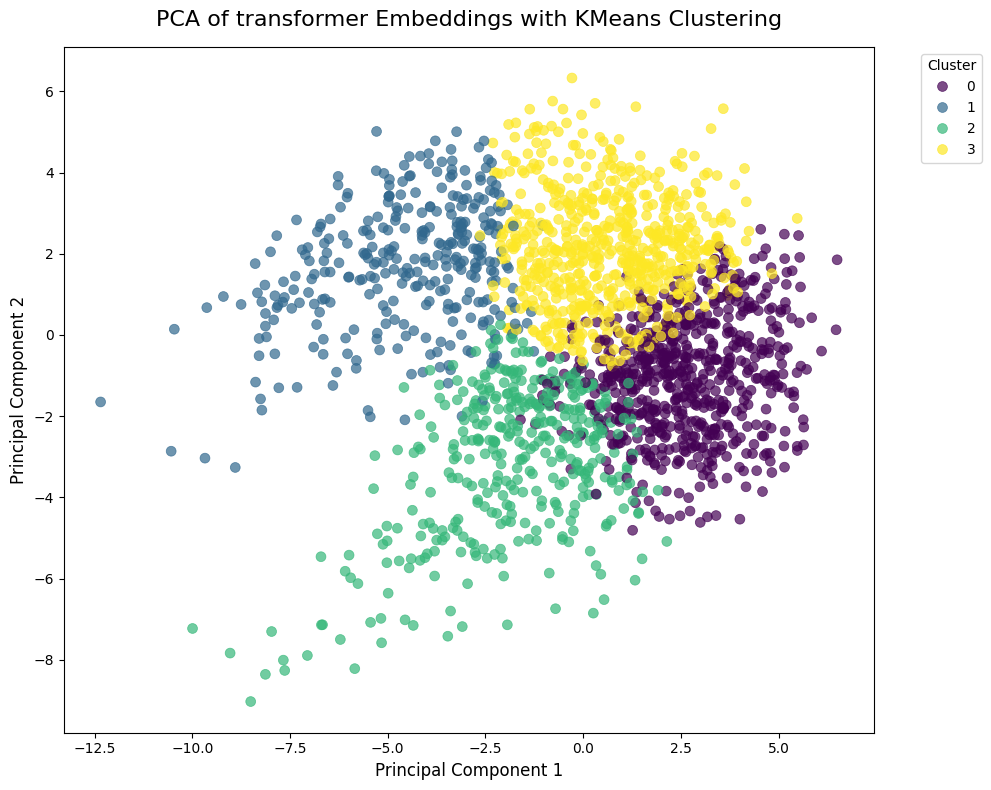

In [17]:
output_path = write_chemiscope(X_transformer, 'transformer')
plot_clusters(X_transformer, 'transformer')

In [18]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, …

# Determine number of clusters

Processing: One-Hot...
Processing: Morgan...
Processing: Transformer...
Processing: ChemProp...
Processing: SOAP...
Processing: ACSF...

Saved to report/qm9/appendix/cluster_metrics.png


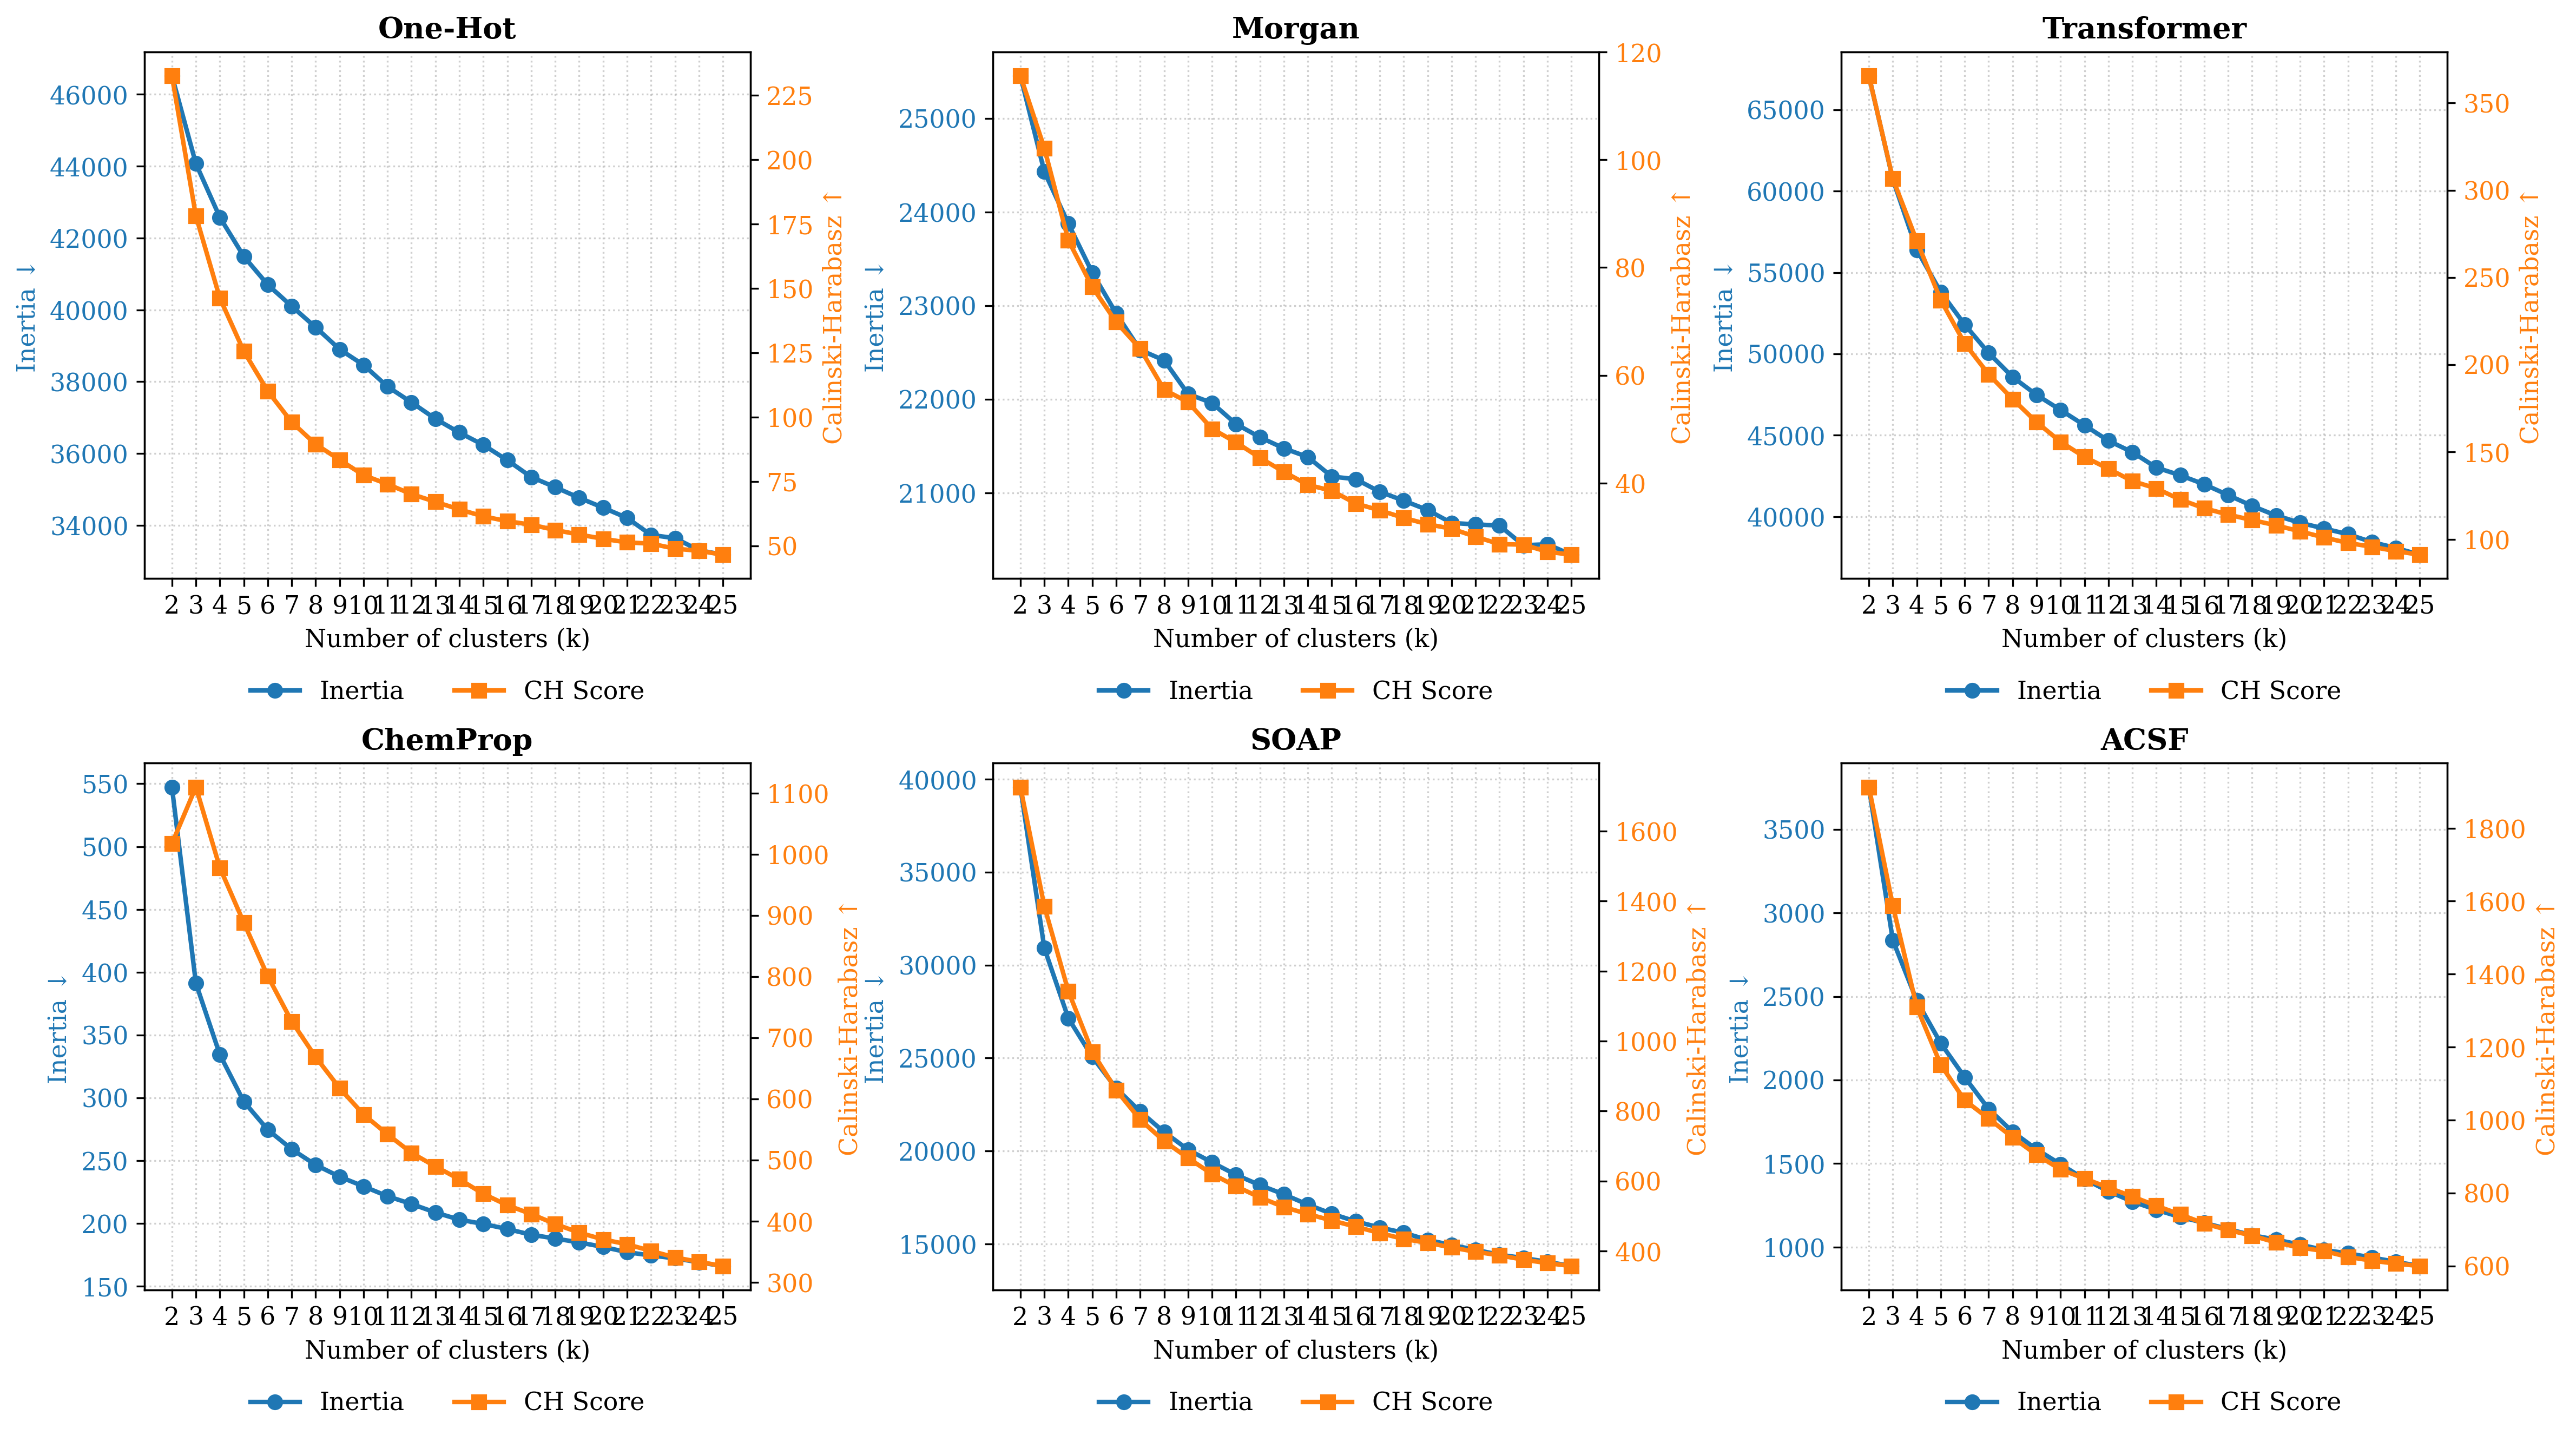

In [ ]:
def plot_individual_clustering_metrics(embeddings_dict, max_k=25, save_path=None):
    # Set overall styling for a clean, academic look
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    })

    k_values = list(range(2, max_k + 1))
    
    # Create a 2x3 grid of subplots for the 6 embeddings
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=300)
    axes = axes.flatten()

    for idx, (name, X) in enumerate(embeddings_dict.items()):
        print(f"Processing: {name}...")
        ax1 = axes[idx]
        
        inertia_vals = []
        ch_vals = []
        
        for k in k_values:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)
            
            inertia_vals.append(model.inertia_)
            ch_vals.append(calinski_harabasz_score(X, labels))
            
        # 1. Plot Inertia on the primary (left) y-axis
        color1 = '#1f77b4' # Muted Blue
        ax1.set_title(name, fontweight='bold')
        ax1.set_xlabel("Number of clusters (k)")
        ax1.set_ylabel("Inertia ↓", color=color1)
        line1 = ax1.plot(k_values, inertia_vals, marker='o', color=color1, linewidth=2, label="Inertia")
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.set_xticks(k_values)
        ax1.grid(True, linestyle=":", alpha=0.6)
        
        # 2. Plot CH on the secondary (right) y-axis
        ax2 = ax1.twinx()
        color2 = '#ff7f0e' # Muted Orange
        ax2.set_ylabel("Calinski-Harabasz ↑", color=color2)
        line2 = ax2.plot(k_values, ch_vals, marker='s', color=color2, linewidth=2, label="CH Score")
        ax2.tick_params(axis='y', labelcolor=color2)
        
        # 3. Combine legends at the bottom of each subplot
        lines = line1 + line2
        labels = [lab.get_label() for lab in lines]
        ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

    # Hide any unused subplots if you pass fewer than 6 embeddings
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    # Add a little extra vertical space between rows for the legends
    plt.subplots_adjust(hspace=0.35, wspace=0.4)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"\nSaved to {save_path}")
        
    plt.show()

embeddings = {
    "One-Hot": X_onehot,
    "Morgan": X_morgan,
    "Transformer": X_transformer,
    "ChemProp": X_chemprop,
    "SOAP": X_soap,
    "ACSF": X_acsf
}

plot_individual_clustering_metrics(embeddings, save_path="report/qm9/appendix/cluster_metrics.png")

# Cluster composition analysis

In [20]:
#print(df["morgan_labels"].value_counts(), df["onehot_labels"].value_counts(), df["transformer_labels"].value_counts(), df["chemprop_labels"].value_counts(), df["soap_labels"].value_counts(), df["acsf_labels"].value_counts())

In [21]:
properties_to_analyze = [
        "mol_weight", "logp", "tpsa", 
        "num_heavy_atoms", "num_rings", "num_aromatic_rings", 
        "num_rotatable_bonds", "fraction_csp3", "h_bond_donors", "h_bond_acceptors",
        "branching_index", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons", "main_chain_length", "raw_token_count",
        "fr_benzene", "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro", "fr_halogen"
    ]

In [ ]:
from pathlib import Path

def generate_cluster_report(df: pl.DataFrame, label_col: str, output_csv: str):
    """
    Generate a cluster profile report for a given label column.

    Args:
        df: Polars DataFrame containing molecule properties and cluster labels.
        label_col: Column name containing cluster labels.
        output_csv: Path to save the CSV report.
    Returns:
        summary_df: Pandas DataFrame with aggregated cluster statistics.
    """
    logger.info(f"Generating report for: '{label_col}'...")

    # Identify numeric columns for aggregation

    properties_to_analyze = [
        "mol_weight", "logp", "tpsa", 
        "num_heavy_atoms", "num_rings", "num_aromatic_rings", 
        "num_rotatable_bonds", "fraction_csp3", "h_bond_donors", "h_bond_acceptors",
        "branching_index", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons", "main_chain_length", "raw_token_count",
        "fr_benzene", "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro", "fr_halogen"
    ]

    # print which of these columns are not numeric
    non_numeric_cols = [
        c for c in properties_to_analyze
        if c not in df.columns or pl.Float64 not in [df[c].dtype, df[c].dtype.__class__]
    ]

    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in properties_to_analyze])
    if non_numeric_cols:
        logger.warning(f"Non-numeric columns in properties_to_analyze: {non_numeric_cols}")

    numeric_cols = [c for c in df.columns if c != label_col and pl.Float64 in [df[c].dtype, df[c].dtype.__class__]]
    
    # Alternatively, if you have a predefined list of properties to analyze:
    # numeric_cols = [p for p in properties_to_analyze if p in df.columns]

    if not numeric_cols:
        logger.warning("No numeric columns found for aggregation.")
        return None

    # Ensure all numeric columns are Float64
    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in numeric_cols])

    # Build aggregation expressions: mean per property + molecule count
    agg_exprs = [pl.col(c).mean().alias(f"avg_{c}") for c in numeric_cols]
    agg_exprs.append(pl.len().alias("molecule_count"))

    # Perform groupby and aggregation
    summary = (
        df.group_by(label_col)
        .agg(agg_exprs)
        .sort(label_col)
    )

    # Convert to Pandas and set label_col as index
    summary_df = summary.to_pandas().set_index(label_col)

    # Ensure output directory exists
    Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(output_csv)

    logger.success(f"Saved: {output_csv}")
    return summary_df

# Example usage for multiple embeddings
for embedding in ["onehot", "morgan", "transformer", "chemprop", "soap", "acsf"]:
    generate_cluster_report(
        df,
        label_col=f"{embedding}_labels",
        output_csv=f"report/qm9/euclidean_baseline/csv/{embedding}_profile.csv"
    )

2026-03-17 14:27:46.034 | INFO     | __main__:generate_cluster_report:17 - Generating report for: 'onehot_labels'...
2026-03-17 14:27:46.072 | WARNING  | __main__:generate_cluster_report:34 - Non-numeric columns in properties_to_analyze: ['mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 'num_rings', 'num_aromatic_rings', 'num_rotatable_bonds', 'h_bond_donors', 'h_bond_acceptors', 'branching_index', 'num_sp_carbons', 'num_sp2_carbons', 'num_sp3_carbons', 'main_chain_length', 'raw_token_count', 'fr_benzene', 'fr_alcohol', 'fr_phenol', 'fr_amine', 'fr_amide', 'fr_carboxylic_acid', 'fr_ester', 'fr_ketone', 'fr_ether', 'fr_nitro', 'fr_halogen']
2026-03-17 14:27:46.157 | SUCCESS  | __main__:generate_cluster_report:66 - Saved: report/qm9/euclidean_baseline/csv/onehot_profile.csv
2026-03-17 14:27:46.158 | INFO     | __main__:generate_cluster_report:17 - Generating report for: 'morgan_labels'...
2026-03-17 14:27:46.159 | WARNING  | __main__:generate_cluster_report:34 - Non-numeric columns in pr

In [23]:
os.listdir()

['umap_clustering_soap_embedding.json.gz',
 '.DS_Store',
 'uv.lock',
 'config',
 'wandb.py',
 'clustering_results.json.gz',
 'clustering_inertia_individual.png',
 'pyproject.toml',
 'tests',
 'utils',
 'models',
 'README.md',
 'results',
 '.gitignore',
 'soap_tsne_clusters.json',
 'figures',
 '.venv',
 'scripts',
 '.python-version',
 'api',
 'report',
 'kmedoids_comparison.png',
 'clustering_comparative_metrics.png',
 '.git',
 '.vscode',
 'main.py',
 'data',
 'notebooks',
 'matrices',
 'src']

In [24]:
qm9.df

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot,soap_embedding,acsf_embedding,coulomb_matrix,chemprop_embedding,onehot_labels,morgan_labels,transformer_labels,chemprop_labels,soap_labels,acsf_labels
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]],list[f64],list[f64],list[f64],list[f64],i32,i32,i32,i32,i32,i32
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…","""""",5,"""Acyclic""",16,0,0,1,0,0,0,0.0,0.0,1.0,0,0,1,0,0,1,2,9,1.103448,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[0.85723, 0.67413, … -0.194341]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.184413, 0.478464, … 0.0]","[2.650031, 1.765813, … 0.0]","[36.858105, 5.493502, … 0.0]","[0.0, 0.07941, … 0.029092]",2,2,2,2,2,1
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""","""""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,0.0,0.0,1,1,1,0,0,0,2,6,1.039883,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0.835795, 0.565978, … 0.348474]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.170095, 0.427155, … 0.0]","[1.94162, 1.53645, … 0.0]","[53.358707, 6.869482, … 0.0]","[0.0, 0.033438, … 0.0]",2,2,1,2,2,1
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0.980759,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[1.035763, 0.256207, … 0.323382]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]","[73.516695, 8.255933, … 0.0]","[0.0, 0.079103, … 0.0]",2,1,1,2,2,1
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""","""""",4,"""Acyclic""",26,0,0,2,0,0,0,1.0,0.0,0.0,0,0,0,2,0,0,3,4,1.105607,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[1.47265, 0.608035, … 0.116478]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]","[36.858105, 29.992443, … 0.0]","[0.0, 0.012863, … 0.0]",2,1,1,2,2,1
"""qm9_4""","""CHN""","""[H]C#N""","""[H]C#N""","""[H][C][#N]""","""""",3,"""Acyclic""",27,0,23,2,0,0,0,1.0,0.0,0.0,0,1,0,1,0,0,2,3,1.092491,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.546197, 0.145142, … -0.164353]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.077737, 0.214865, … 0.0]","[0.540542, 0.358622, … 0.0]","[53.358707, 36.206892, … 0.0]","[0.